In [ ]:
# mamba activate spatiocore_spatial_env
import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")
sc.settings.verbosity = 1
%config InlineBackend.figure_format = 'retina'
# ---- Publication-quality style ----------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 100,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
sns.set_context("paper")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [29]:
from matplotlib.lines import Line2D

class PunchPCAPlotter:
    def __init__(
        self,
        pca_df,
        punch_ids,
        adata,
        punch_col="punch_id",
        condition_col="condition",
        type_col="type",
        mouse_col="mouse",
    ):
        self.pca_df = pca_df.copy()
        self.punch_ids = [str(x) for x in punch_ids]
        self.adata = adata
        self.punch_col = punch_col
        self.condition_col = condition_col
        self.type_col = type_col
        self.mouse_col = mouse_col

    def _metadata_from_adata(self):
        obs = self.adata.obs.copy()
        required_cols = [self.punch_col, self.condition_col, self.type_col, self.mouse_col]
        missing_cols = [col for col in required_cols if col not in obs.columns]

        if missing_cols:
            raise KeyError(
                "Missing metadata columns in adata.obs: "
                + ", ".join(missing_cols)
                + f". Available columns include: {list(obs.columns[:20])}"
            )

        meta = obs[required_cols].drop_duplicates().copy()
        meta[self.punch_col] = meta[self.punch_col].astype(str)
        meta = meta[meta[self.punch_col].isin(self.punch_ids)]

        duplicate_punches = meta[self.punch_col][meta[self.punch_col].duplicated()].unique()
        if len(duplicate_punches) > 0:
            meta = meta.drop_duplicates(subset=self.punch_col, keep="first")

        meta = meta.rename(columns={self.punch_col: "punch_id"})

        alias_map = {
            self.condition_col: "condition",
            self.type_col: "type",
            self.mouse_col: "mouse",
        }
        for original_col, alias_col in alias_map.items():
            if original_col in meta.columns and alias_col not in meta.columns:
                meta[alias_col] = meta[original_col]

        for col in meta.columns:
            if col != "punch_id":
                meta[col] = meta[col].astype(str)

        return meta

    def _plot_data(self):
        df = self.pca_df.copy()

        if "punch_id" in df.index.names:
            if "punch_id" in df.columns:
                df = df.reset_index(drop=True)
            else:
                df = df.reset_index()

        if "punch_id" not in df.columns:
            df["punch_id"] = df.index.astype(str)

        df["punch_id"] = df["punch_id"].astype(str)
        df = df[df["punch_id"].isin(self.punch_ids)].copy()

        missing_pc_cols = [col for col in ["PC1", "PC2"] if col not in df.columns]
        if missing_pc_cols:
            raise KeyError(f"pca_df must contain columns: {missing_pc_cols}")

        meta = self._metadata_from_adata()

        overlapping_cols = [
            col for col in meta.columns
            if col != "punch_id" and col in df.columns
        ]
        if overlapping_cols:
            df = df.drop(columns=overlapping_cols)

        plot_df = df.merge(meta, on="punch_id", how="left")

        missing_metadata = plot_df[
            [self.condition_col, self.type_col, self.mouse_col]
        ].isna().any(axis=1)

        if missing_metadata.any():
            missing_ids = plot_df.loc[missing_metadata, "punch_id"].tolist()
            raise ValueError(
                "Metadata was not found for punch_id values: "
                + ", ".join(missing_ids)
            )

        return plot_df

    @staticmethod
    def _value_order(values):
        values = pd.Series(values).dropna().astype(str).unique().tolist()
        return sorted(values, key=lambda x: (not x.isdigit(), int(x) if x.isdigit() else x))

    def _resolve_plot_column(self, df, requested_col):
        if requested_col in df.columns:
            return requested_col

        aliases = {
            "condition": self.condition_col,
            self.condition_col: "condition",
            "type": self.type_col,
            self.type_col: "type",
            "mouse": self.mouse_col,
            self.mouse_col: "mouse",
        }
        alias_col = aliases.get(requested_col)

        if alias_col in df.columns:
            return alias_col

        raise KeyError(
            f"Column '{requested_col}' was not found in the plot data. "
            f"Available columns: {list(df.columns)}"
        )

    def _condition_color_map(self, values):
        base_colors = {
            "Mock": "#4C72B0",
            "CAR": "#55A868",
            "IL15": "#C44E52",
            "IL21": "#8172B3",
            "both": "#937860",
        }

        condition_order = ["Mock", "CAR", "IL15", "IL21", "both"]
        color_values = [
            value for value in condition_order
            if value in pd.Series(values).dropna().astype(str).unique()
        ]

        extra_values = [
            value for value in self._value_order(values)
            if value not in color_values
        ]
        color_values = color_values + extra_values

        palette = list(plt.get_cmap("tab20").colors)
        colors = {}

        next_palette_idx = 0
        for value in color_values:
            if value in base_colors:
                colors[value] = base_colors[value]
            else:
                colors[value] = palette[next_palette_idx % len(palette)]
                next_palette_idx += 1

        return colors

    def _type_edge_color_map(self, values):
        base_edge_colors = {
            "Primary": "#4C72B0",
            "Metastasis": "#DD8452",
        }

        edge_values = self._value_order(values)
        edge_colors = {}

        for value in edge_values:
            edge_colors[value] = base_edge_colors.get(value, "black")

        return edge_colors

    def _marker_map(self, values):
        marker_list = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "h", "H", "*", "p", "8"]
        marker_values = self._value_order(values)

        return {
            value: marker_list[i % len(marker_list)]
            for i, value in enumerate(marker_values)
        }

    def plot(
        self,
        title="Pseudo-bulk PCA by condition",
        explained_variance=None,
        color_by="condition",
        edge_by="type",
        marker_by="mouse",
        label_by="punch_id",
        save_prefix=None,
        dpi=100,
    ):
        df = self._plot_data()

        color_col = self._resolve_plot_column(df, color_by)
        edge_col = self._resolve_plot_column(df, edge_by)
        marker_col = self._resolve_plot_column(df, marker_by)
        label_col = self._resolve_plot_column(df, label_by)

        df[color_col] = df[color_col].astype(str)
        df[edge_col] = df[edge_col].astype(str)
        df[marker_col] = df[marker_col].astype(str)
        df[label_col] = df[label_col].astype(str)

        colors = self._condition_color_map(df[color_col])
        edge_colors = self._type_edge_color_map(df[edge_col])
        markers = self._marker_map(df[marker_col])

        color_values = self._value_order(df[color_col])
        edge_values = self._value_order(df[edge_col])
        marker_values = self._value_order(df[marker_col])

        fig, ax = plt.subplots(figsize=(6.2, 5.0), dpi=dpi)

        for _, row in df.iterrows():
            fill_value = row[color_col]
            edge_value = row[edge_col]
            marker_value = row[marker_col]

            ax.scatter(
                row["PC1"],
                row["PC2"],
                s=135,
                color=colors.get(fill_value, "gray"),
                marker=markers.get(marker_value, "o"),
                edgecolor=edge_colors.get(edge_value, "black"),
                linewidth=0.8,
                alpha=0.95,
                zorder=3,
            )

            ax.text(
                row["PC1"],
                row["PC2"],
                row[label_col],
                ha="center",
                va="center",
                fontsize=6.0,
                color="black",
                fontweight="normal",
                zorder=4,
            )

        if explained_variance is not None:
            ax.set_xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% variance)")
            ax.set_ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% variance)")
        else:
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")

        ax.set_title(title, fontweight="bold", pad=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.axhline(0, color="0.88", linewidth=0.8, zorder=0)
        ax.axvline(0, color="0.88", linewidth=0.8, zorder=0)
        ax.tick_params(direction="out", length=4, width=1)

        color_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                label=value,
                markerfacecolor=colors.get(value, "gray"),
                markeredgecolor="black",
                markersize=8,
            )
            for value in color_values
        ]

        legend1 = ax.legend(
            handles=color_handles,
            title=color_by,
            frameon=False,
            bbox_to_anchor=(1.02, 1.0),
            loc="upper left",
            borderaxespad=0,
        )
        ax.add_artist(legend1)

        edge_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                label=value,
                markerfacecolor="white",
                markeredgecolor=edge_colors.get(value, "black"),
                markeredgewidth=1.8,
                markersize=8,
            )
            for value in edge_values
        ]

        legend2 = ax.legend(
            handles=edge_handles,
            title=edge_by,
            frameon=False,
            bbox_to_anchor=(1.02, 0.62),
            loc="upper left",
            borderaxespad=0,
        )
        ax.add_artist(legend2)

        marker_handles = [
            Line2D(
                [0], [0],
                marker=markers[value],
                linestyle="",
                label=value,
                markerfacecolor="white",
                markeredgecolor="black",
                markersize=8,
            )
            for value in marker_values
        ]

        ax.legend(
            handles=marker_handles,
            title=marker_by,
            frameon=False,
            bbox_to_anchor=(1.02, 0.34),
            loc="upper left",
            borderaxespad=0,
        )

        plt.tight_layout()

        return fig, ax

In [5]:
pathout = '/data/HiTIF/data/spatialomics/neuroblastoma/data/andata_orig'
adata = sc.read_h5ad(os.path.join(pathout, "andata_nb_orig_metadata.h5ad"))
sc.pp.calculate_qc_metrics(adata, percent_top=None,log1p=False, inplace=True)

In [6]:
SAMPLE_COL = "punch_id"
COUNT_COL = "total_counts"
GENE_COL = "n_genes_by_counts"

MIN_TOTAL_COUNTS = 50
MIN_GENES_BY_COUNTS = 20
MAX_TOTAL_COUNTS_Q = 0.995
MIN_CELLS_PER_GENE = 10

max_total_counts = adata.obs[COUNT_COL].quantile(MAX_TOTAL_COUNTS_Q)

qc_keep = (
    (adata.obs[COUNT_COL] >= MIN_TOTAL_COUNTS) &
    (adata.obs[GENE_COL] >= MIN_GENES_BY_COUNTS) &
    (adata.obs[COUNT_COL] <= max_total_counts)
)
adata_qc = adata[qc_keep].copy()
sc.pp.filter_genes(adata_qc, min_cells=MIN_CELLS_PER_GENE)

In [ ]:
pb_raw = (
    adata_qc.to_df()
    .groupby(adata_qc.obs["punch_id"].astype(str))
    .mean()
)
adata_norm = adata_qc.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
# sc.pp.log1p(adata_norm)

pb_norm = (
    adata_norm.to_df()
    .groupby(adata_norm.obs["punch_id"].astype(str))
    .mean()
)

punch = adata_qc.obs["punch_id"].astype(str)
mean_area = (
    adata_qc.obs["cell_area"]
    .groupby(punch)
    .mean()
)

pb_area_norm = pb_raw.div(mean_area, axis=0)

In [14]:
mouse_id_list = ['188.0','189.0','185.0','192.0','181.0','195.0']
punch_lists = []
for mouse_id in mouse_id_list:
    punch_curr = adata_qc.obs.loc[adata_qc.obs['mouse_id'] == mouse_id, 'punch_id'].astype(str).unique().tolist()
    punch_lists = punch_lists + punch_curr
    del punch_curr

In [21]:
pb_raw_init = pb_raw.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

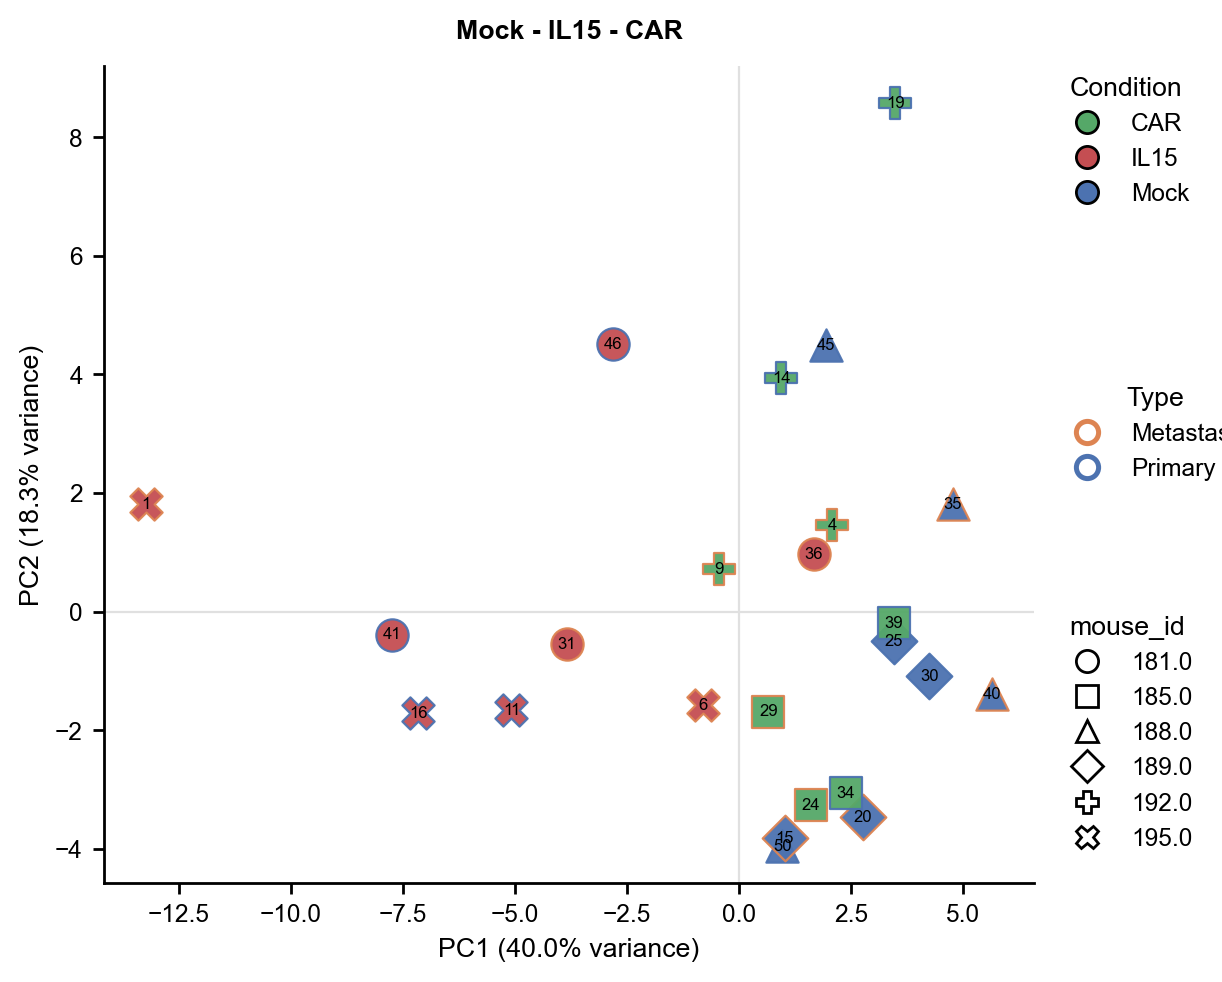

In [30]:
plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

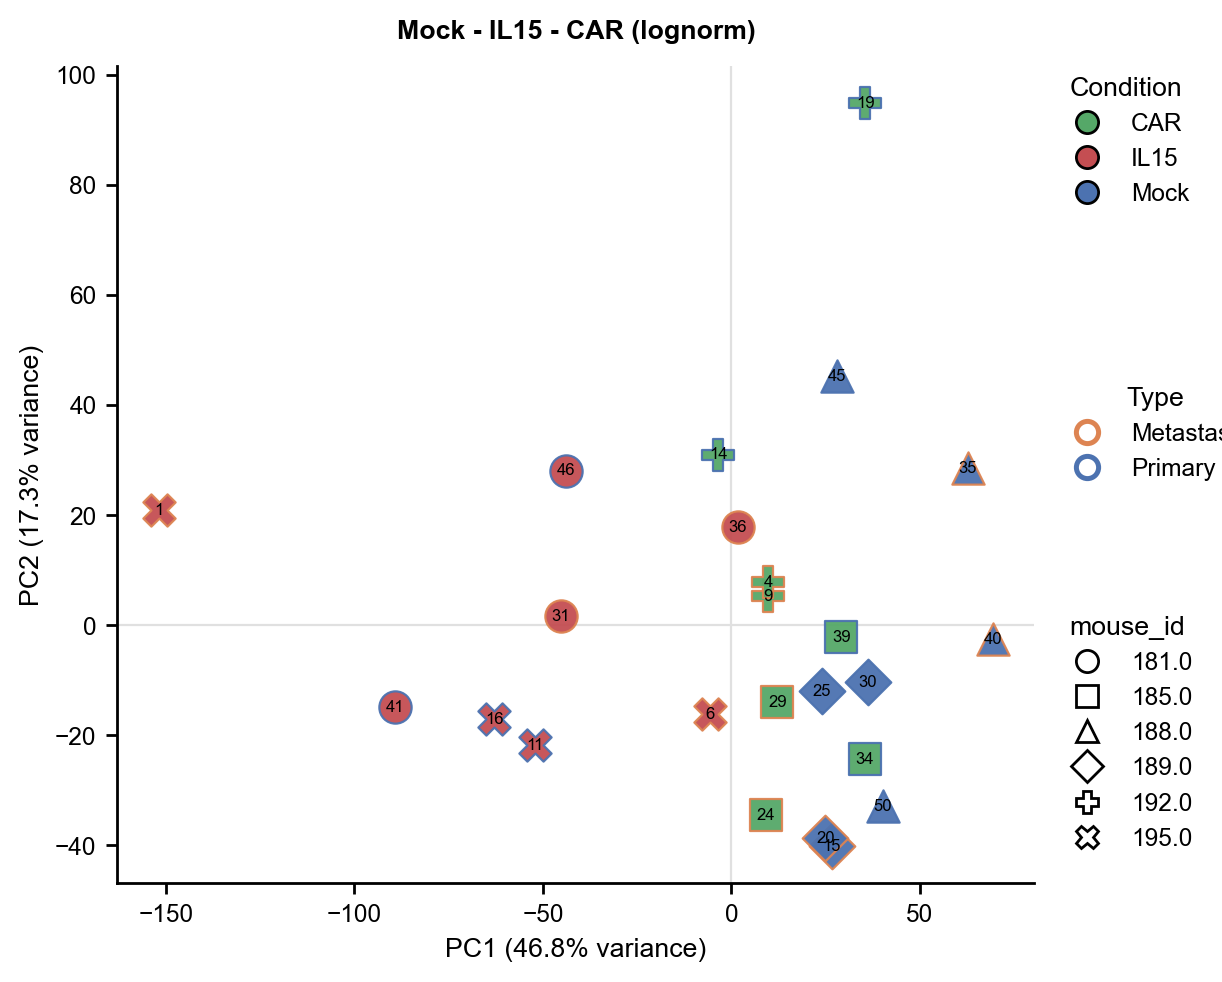

In [31]:
pb_raw_init = pb_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (lognorm)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

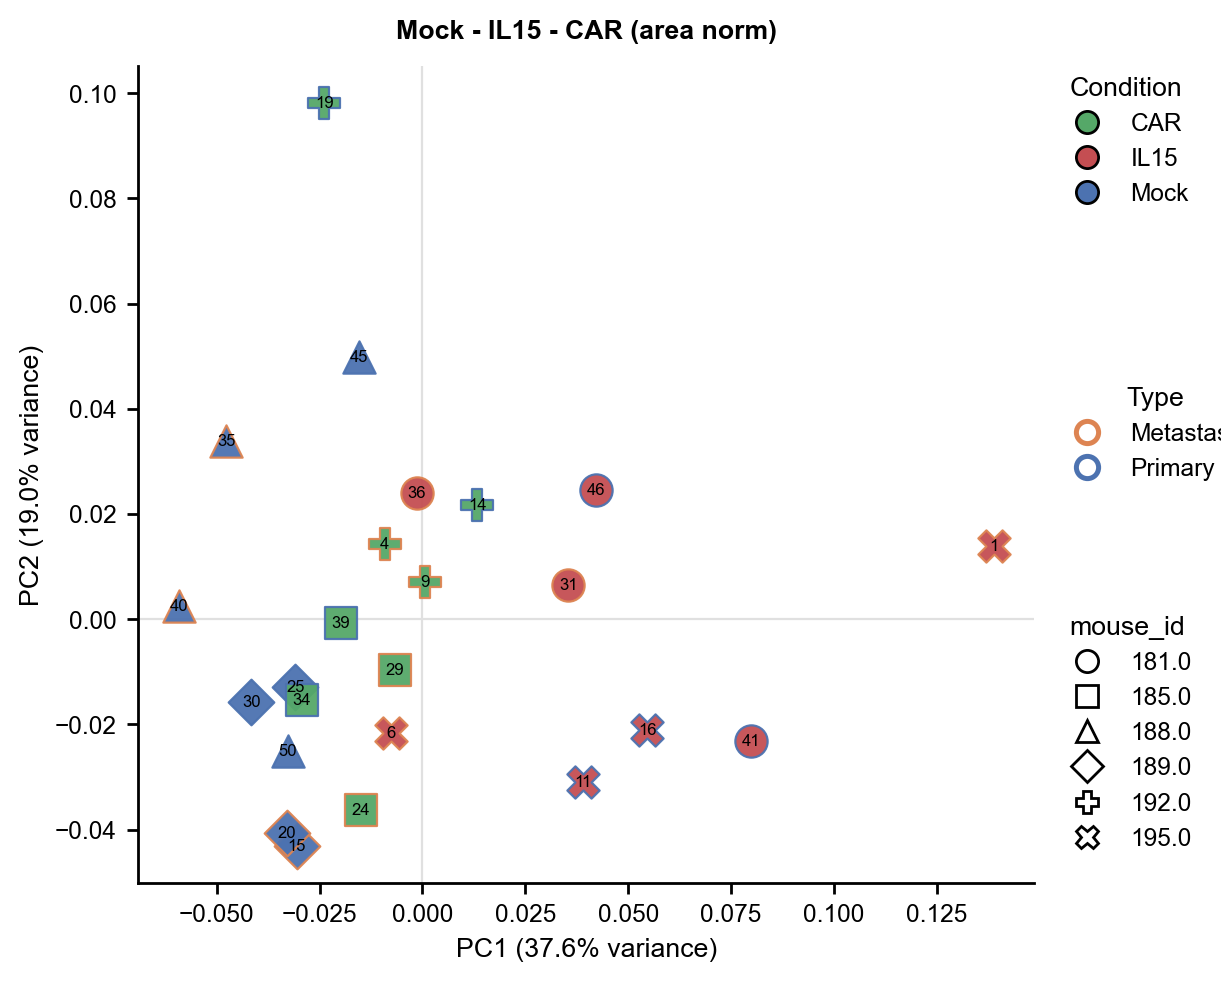

In [32]:
pb_raw_init = pb_area_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (area norm)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

HVG

In [33]:
adata_hvg = adata_qc.copy()
adata_hvg.layers["count"] = adata_hvg.X.copy()
sc.pp.normalize_total(adata_hvg, target_sum=1e4)
sc.pp.log1p(adata_hvg)
adata_hvg.layers["log_norm"] = adata_hvg.X.copy()
sc.pp.highly_variable_genes(
                adata_hvg,
                n_top_genes=2000,
                flavor="seurat",
            )
adata_hvg.X = adata_hvg.layers["count"].copy()
adata_hvg_count = adata_hvg[:, adata_hvg.var["highly_variable"]].copy()

In [34]:
pb_raw = (
    adata_hvg_count.to_df()
    .groupby(adata_hvg_count.obs["punch_id"].astype(str))
    .mean()
)
adata_norm = adata_hvg_count.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
# sc.pp.log1p(adata_norm)

pb_norm = (
    adata_norm.to_df()
    .groupby(adata_norm.obs["punch_id"].astype(str))
    .mean()
)

punch = adata_hvg_count.obs["punch_id"].astype(str)
mean_area = (
    adata_hvg_count.obs["cell_area"]
    .groupby(punch)
    .mean()
)

pb_area_norm = pb_raw.div(mean_area, axis=0)

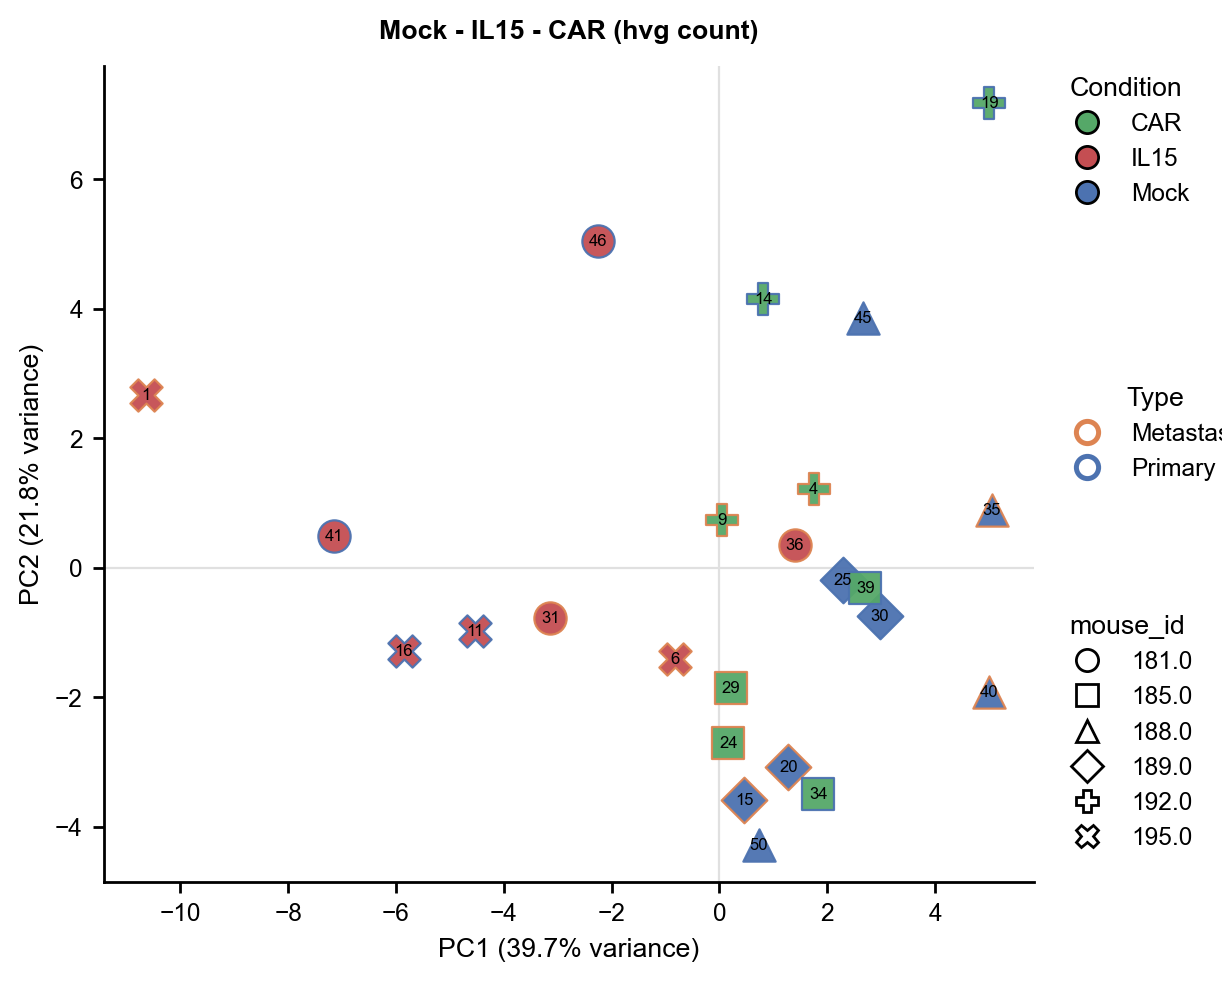

In [35]:
pb_raw_init = pb_raw.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (hvg count)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

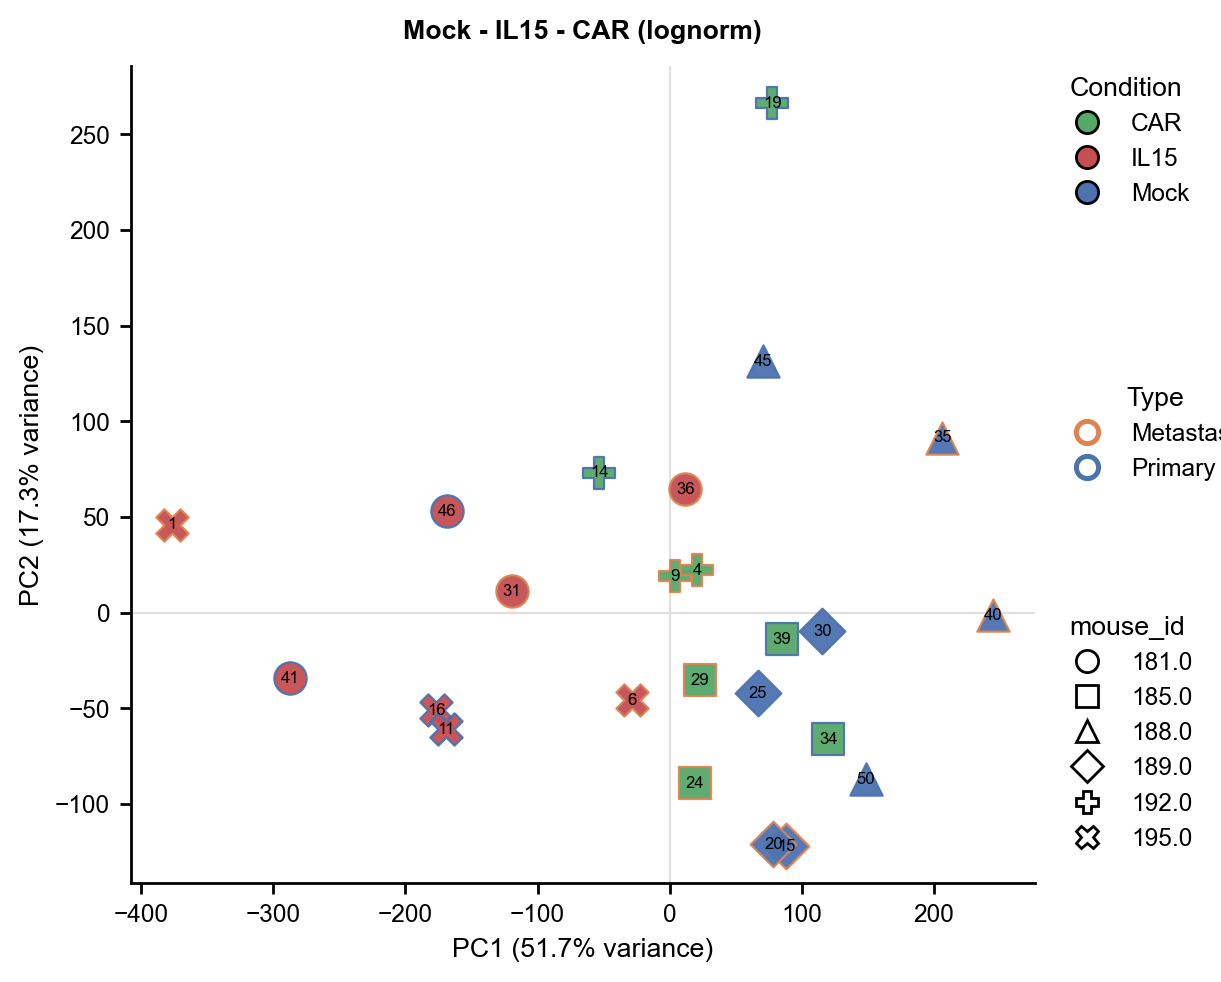

In [36]:
pb_raw_init = pb_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (lognorm)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

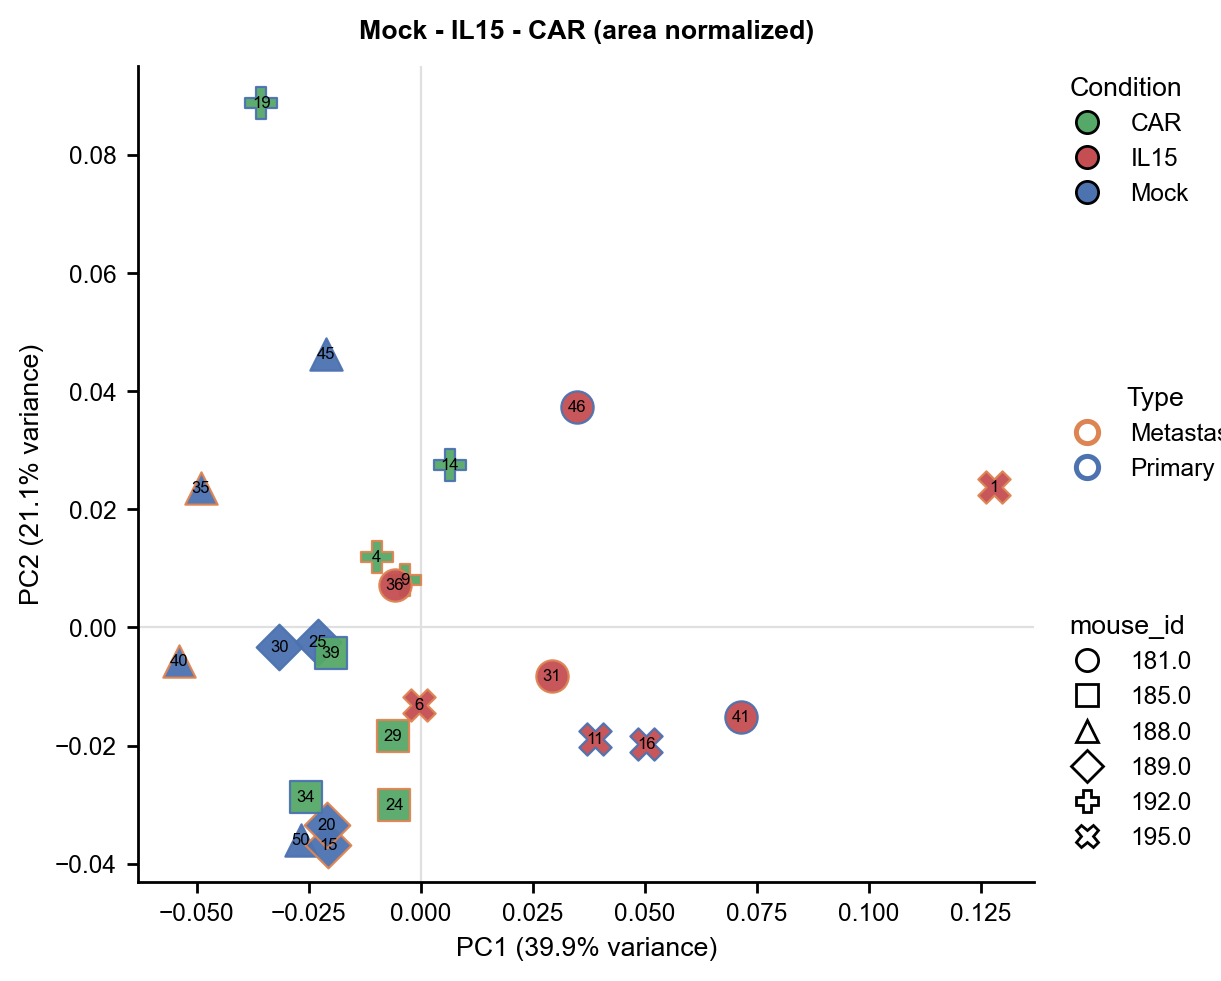

In [38]:
pb_raw_init = pb_area_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (area normalized)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

### Add all data

In [39]:
mouse_id_list = ['188.0','189.0','185.0','192.0','181.0','195.0','187.0','193.0','190.0','182.0','194.0']
punch_lists = []
for mouse_id in mouse_id_list:
    punch_curr = adata_qc.obs.loc[adata_qc.obs['mouse_id'] == mouse_id, 'punch_id'].astype(str).unique().tolist()
    punch_lists = punch_lists + punch_curr
    del punch_curr

In [44]:
pb_raw = (
    adata_qc.to_df()
    .groupby(adata_qc.obs["punch_id"].astype(str))
    .mean()
)
adata_norm = adata_qc.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
# sc.pp.log1p(adata_norm)

pb_norm = (
    adata_norm.to_df()
    .groupby(adata_norm.obs["punch_id"].astype(str))
    .mean()
)

punch = adata_qc.obs["punch_id"].astype(str)
mean_area = (
    adata_qc.obs["cell_area"]
    .groupby(punch)
    .mean()
)

pb_area_norm = pb_raw.div(mean_area, axis=0)

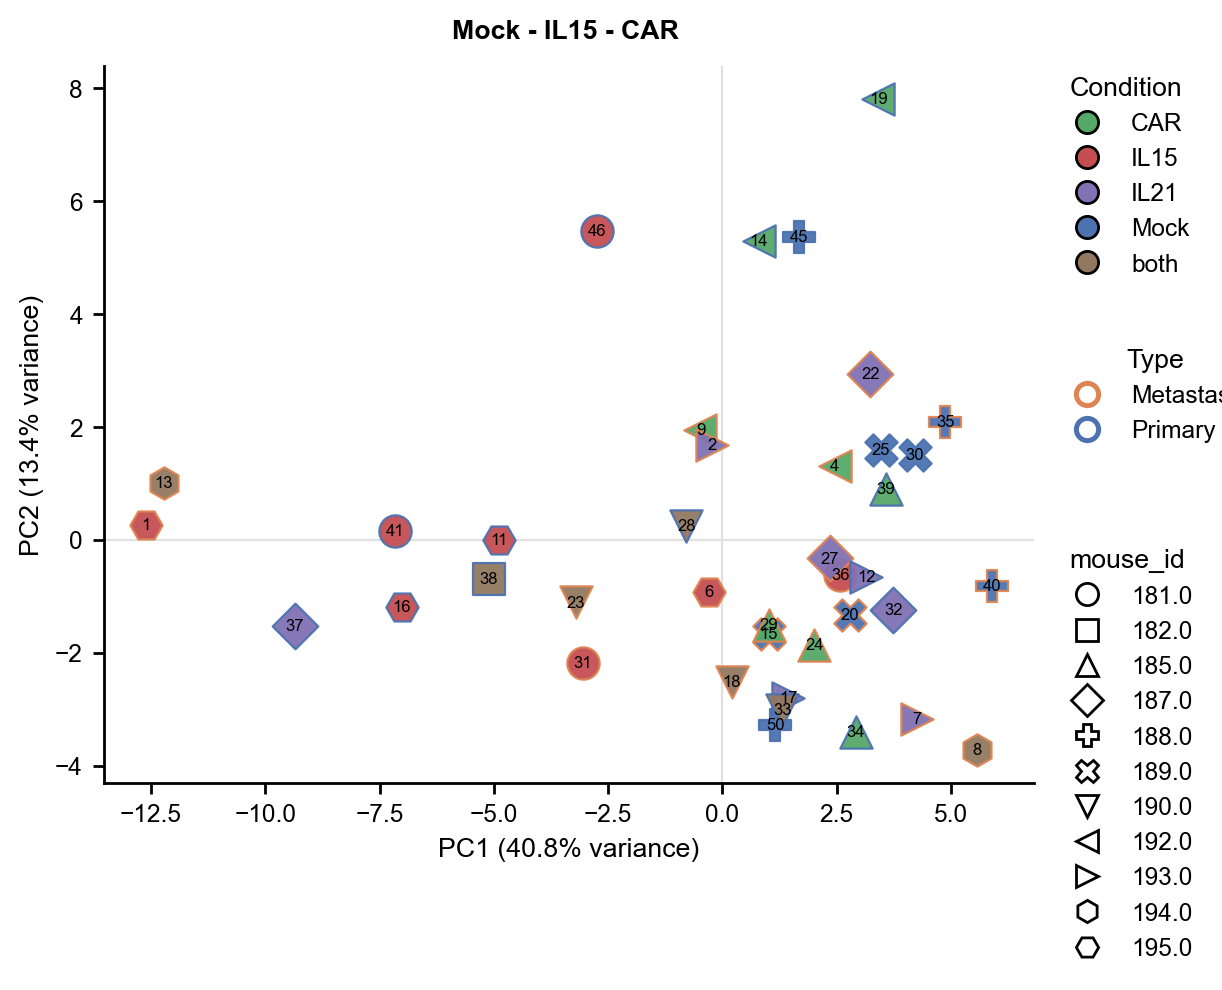

In [48]:
pb_raw_init = pb_raw.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR ",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

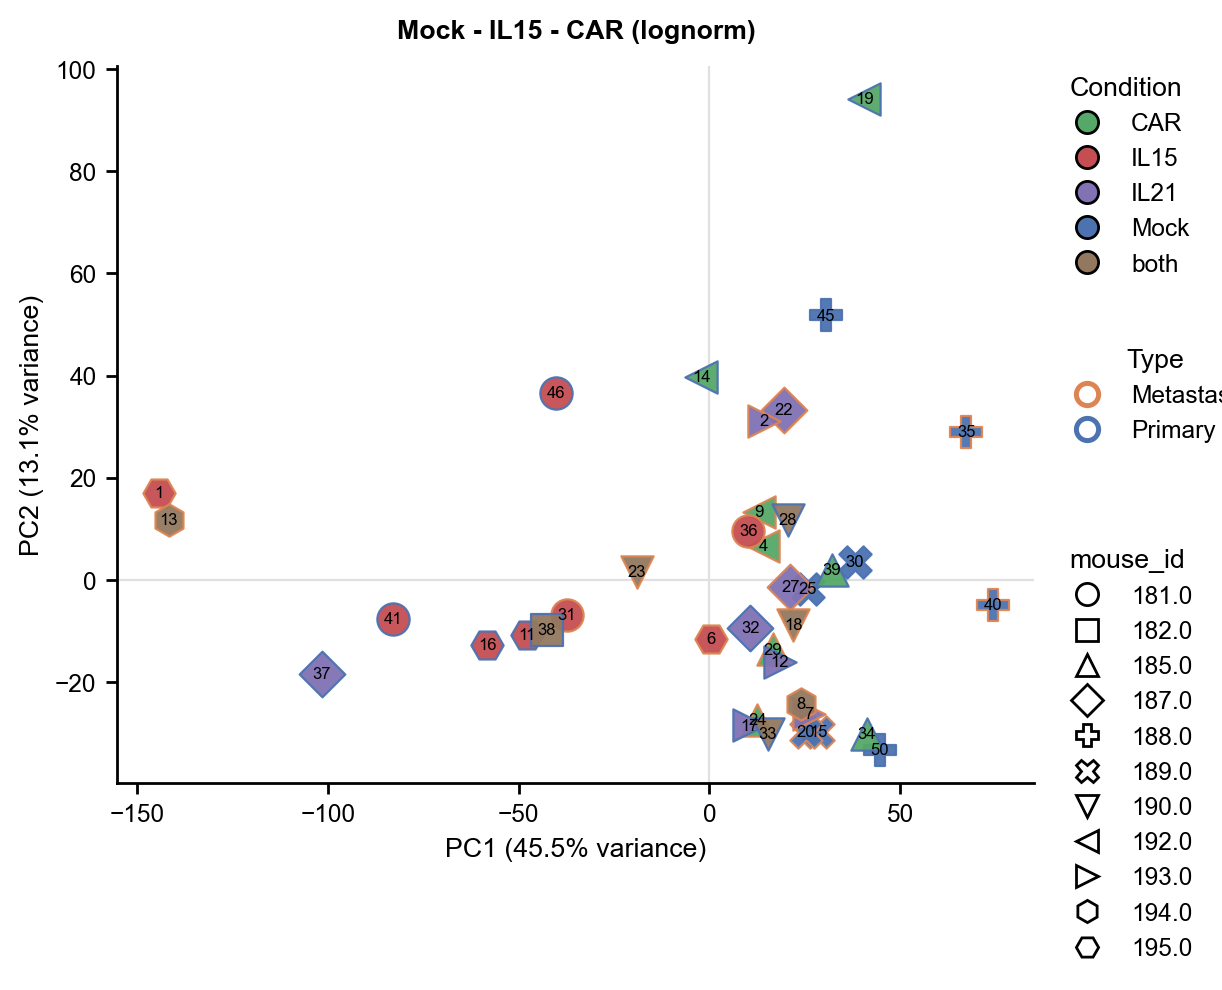

In [46]:
pb_raw_init = pb_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (lognorm)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

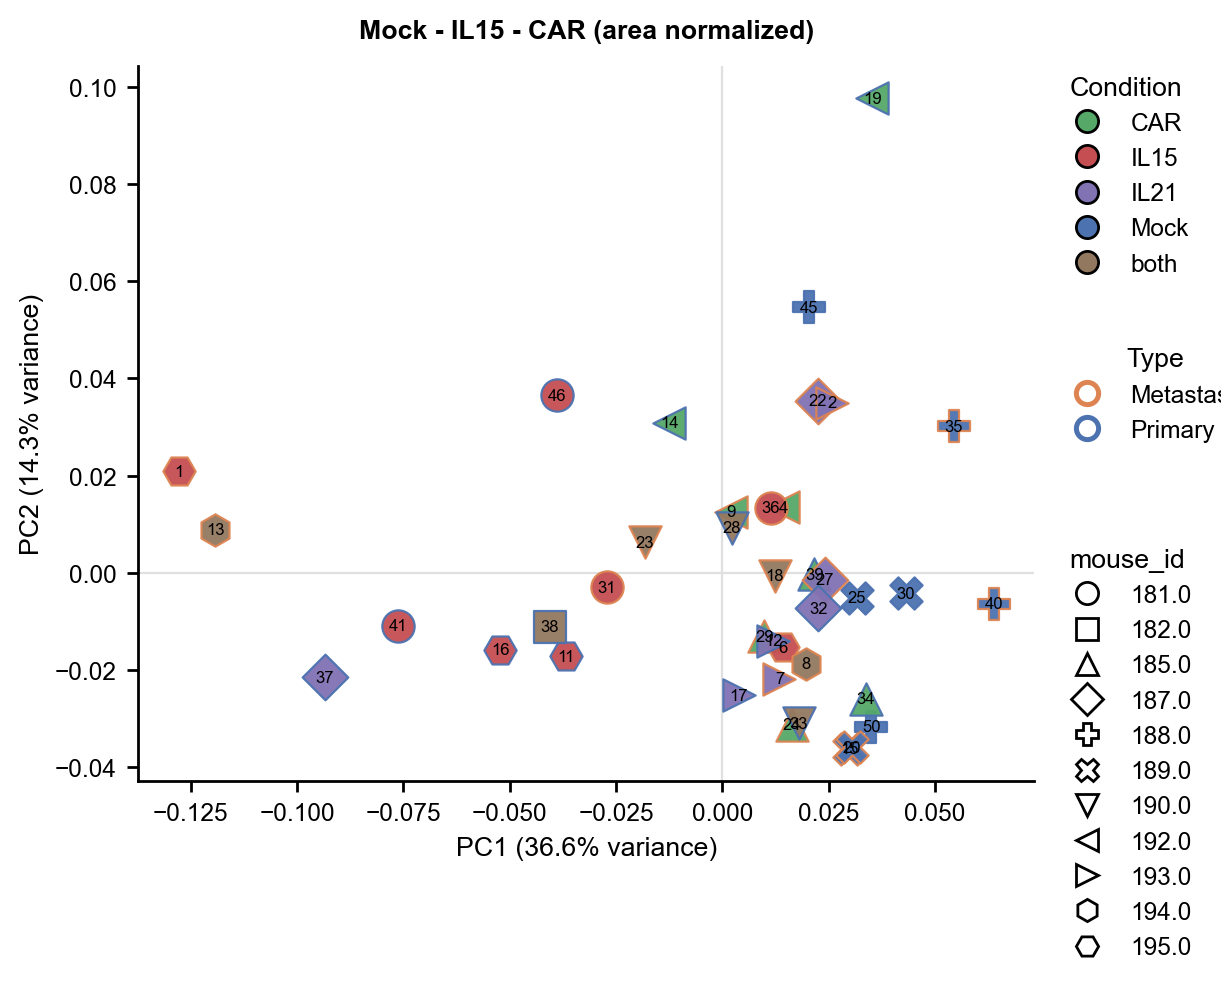

In [47]:
pb_raw_init = pb_area_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (area normalized)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

# HVG all conditions

In [40]:
pb_raw = (
    adata_hvg_count.to_df()
    .groupby(adata_hvg_count.obs["punch_id"].astype(str))
    .mean()
)
adata_norm = adata_hvg_count.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
# sc.pp.log1p(adata_norm)

pb_norm = (
    adata_norm.to_df()
    .groupby(adata_norm.obs["punch_id"].astype(str))
    .mean()
)

punch = adata_hvg_count.obs["punch_id"].astype(str)
mean_area = (
    adata_hvg_count.obs["cell_area"]
    .groupby(punch)
    .mean()
)

pb_area_norm = pb_raw.div(mean_area, axis=0)

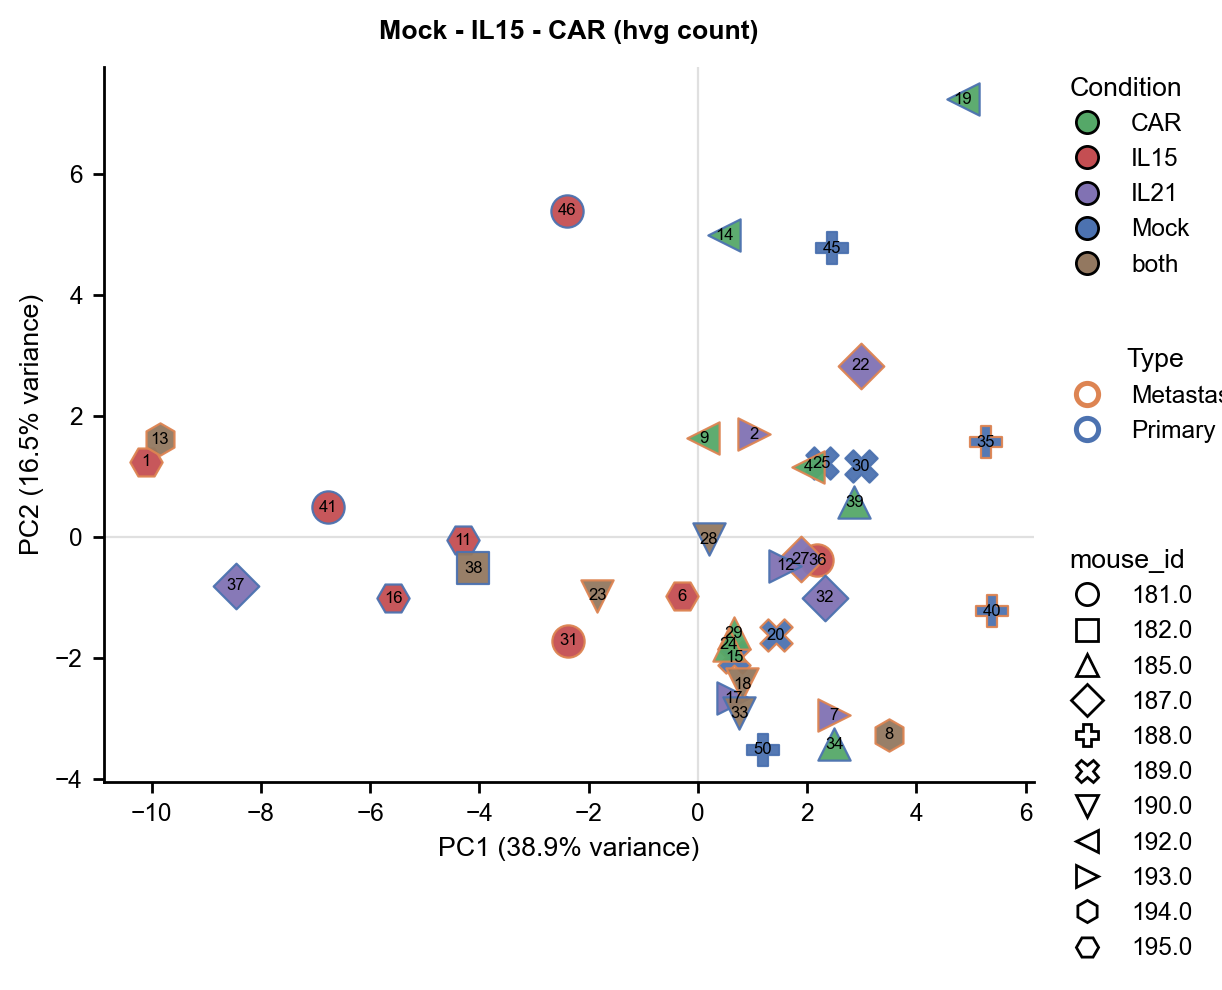

In [41]:
pb_raw_init = pb_raw.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (hvg count)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

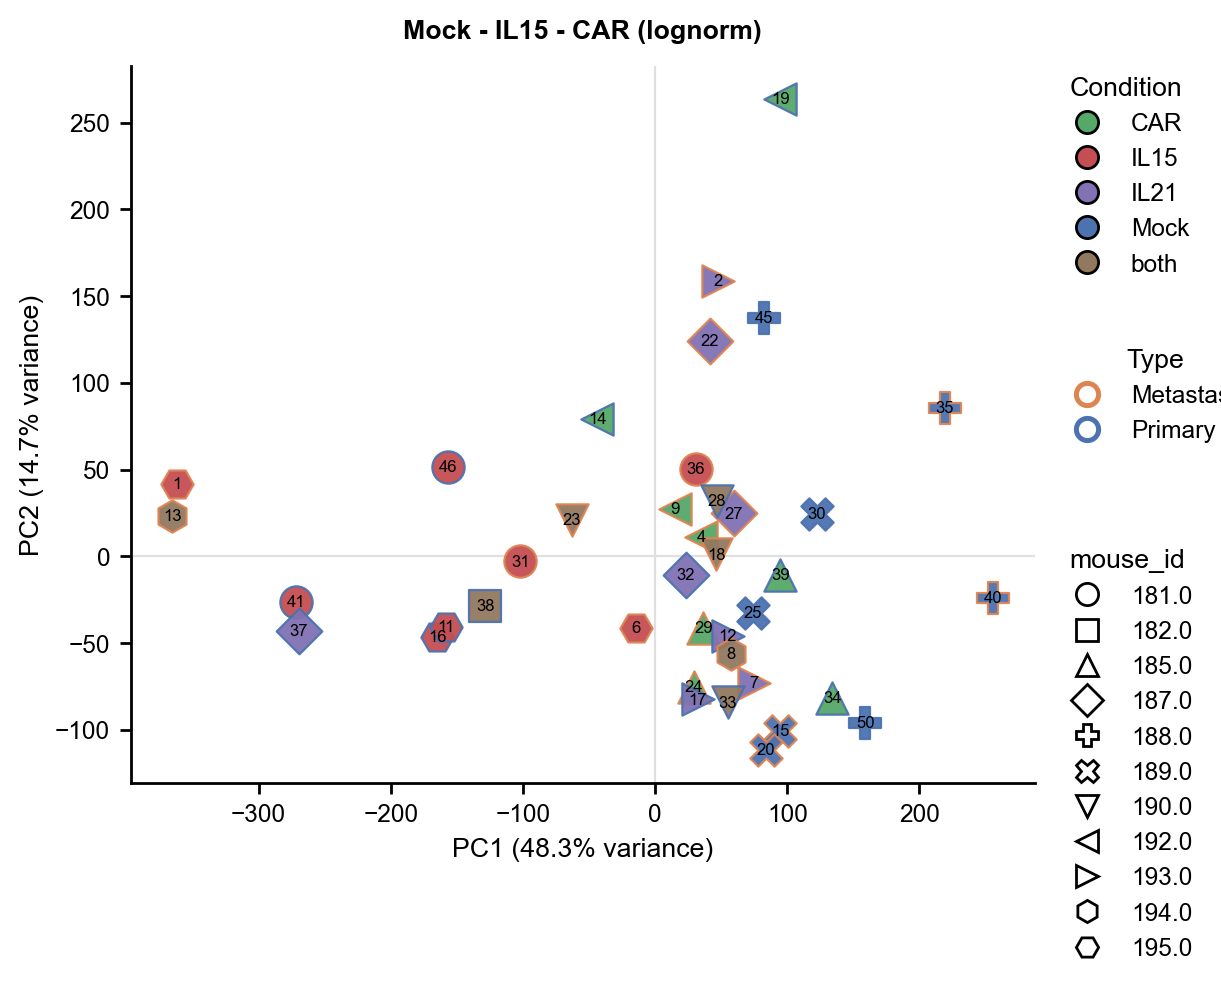

In [42]:
pb_raw_init = pb_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (lognorm)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()

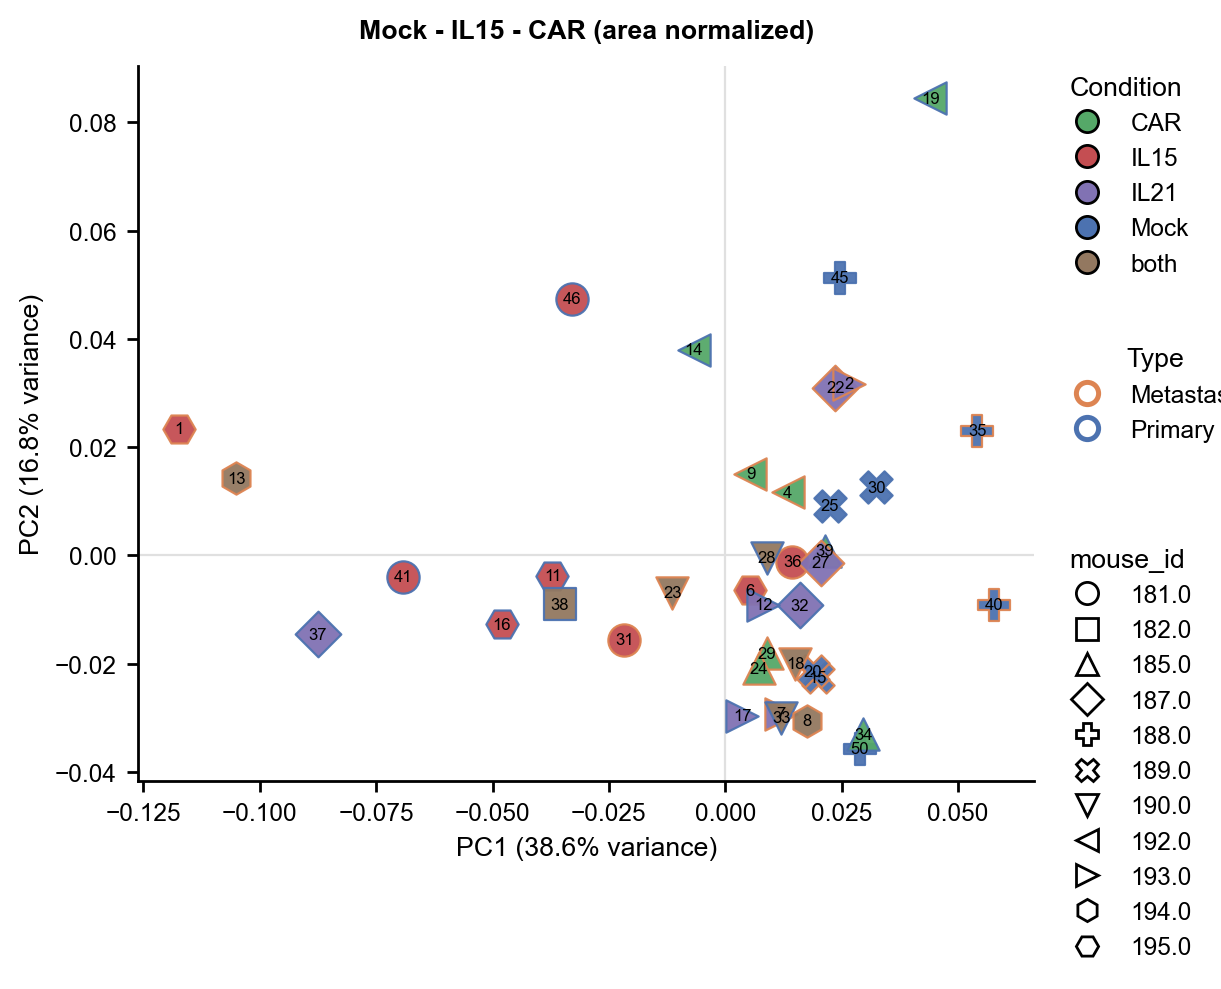

In [43]:
pb_raw_init = pb_area_norm.loc[punch_lists]
pca = PCA(n_components=2)
coords_raw = pca.fit_transform(pb_raw_init)
pca_raw_df = pd.DataFrame(
    coords_raw,
    index=pb_raw_init.index,
    columns=["PC1", "PC2"]
)

plotter = PunchPCAPlotter(
    pca_df=pca_raw_df,
    punch_ids=punch_lists,
    adata=adata_qc,
    punch_col="punch_id",
    condition_col="Condition",
    type_col="Type",
    mouse_col="mouse_id",
)

fig, ax = plotter.plot(
    title="Mock - IL15 - CAR (area normalized)",
    explained_variance=pca.explained_variance_ratio_,
    color_by="Condition",
    edge_by="Type",
    marker_by="mouse_id",
    label_by="punch_id",
)

plt.show()